### Notebook Execution Order

- To ensure the project runs correctly, you have to make sure that the notebook `23127130_23127168_23127231_23127238_23127269.ipynb` **MUST** be run first, because it performs the dataset merging and preparation steps required for the other notebooks.

- After that, the remaining notebooks can be run, but to follow the order of the Objective, you should run like this order:
    1. `23127130_23127168_23127231_23127238_23127269.ipynb`
    2. `23127130_23127238.ipynb`
    3. `23127168.ipynb`
    4. `23127231_23127269.ipynb`

### YouTube Presentation

- Presentation video link: [YouTube link](YOUR_YOUTUBE_LINK_HERE)

## Task Assignment

This notebook was completed by two team members working on the `Economy` topic, with 5 analysis objectives as follows:

11. Analyze the growth trend of GDP per capita of 11 ASEAN countries from 2000 to 2020, thereby categorizing economies by income levels and catch-up speeds.
12. Measure the level of trade integration of ASEAN countries to identify which nations have the highest and lowest economic openness, and analyze their trends over time.
13. Analyze the relationship between FDI inflows and economic growth to determine if foreign direct investment coincides with periods of rapid expansion.
14. Analyze the external debt vulnerability of ASEAN countries by comparing debt scale, debt service burden, and foreign exchange reserve capacity.
15. Compare the domestic accumulation capability against the reliance on external resources to identify the underlying growth models of ASEAN countries.

Based on that, we divided the work as follows:

| Student ID | Full Name | Task |
|------------|-----------|------|
| 23127269 | Đỗ Đăng Nhật Tiến | Completed Objectives 11 to 13 |
| 23127231 | Tô Thảo My | Completed Objectives 14 to 15 |


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
df = pd.read_csv('SoutheastAsianData.csv')

## Subgroup: Economic Development & Integration

#### 11. Analyze the growth trend of GDP per capita of 11 ASEAN countries from 2000 to 2020, thereby categorizing economies by income levels and catch-up speeds.

- **Data field:**
  - `GDP per capita (constant 2015 US$)`: Reflects the average income level and relative economic size of each citizen after adjusting for inflation, allowing for an objective wealth comparison.
  - `GDP per capita growth (annual %)`: Measures the annual growth rate, highlighting the "catch-up effect" of developing countries.

- **Chart type:** Multi-line chart (Linear and Log Scale) because it clearly illustrates the absolute divergence, the massive wealth gap, and the catch-up speed (slope) of lower-income countries over time.

- **Expected insight:** Singapore and Brunei will be in the high-income group, far ahead of the rest. The CLMV group (Cambodia, Laos, Myanmar, Vietnam) will show a steeper growth curve, reflecting their catch-up process. The absolute gap between countries remains large.

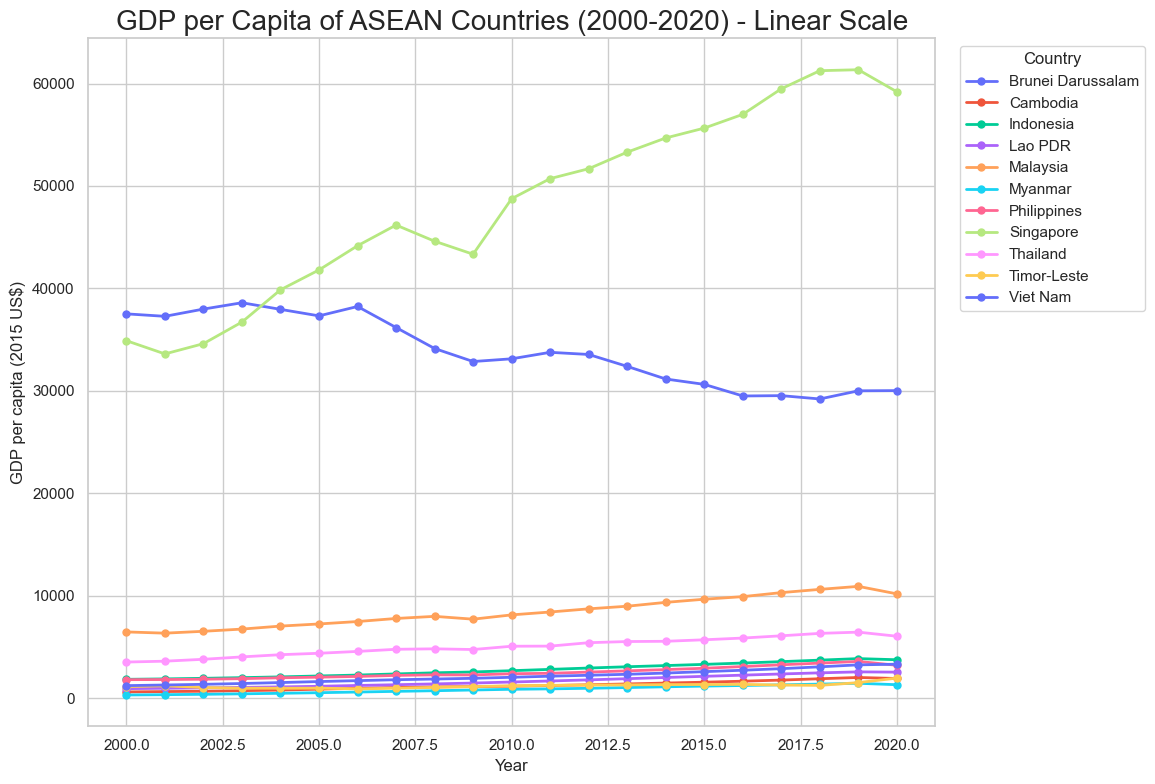

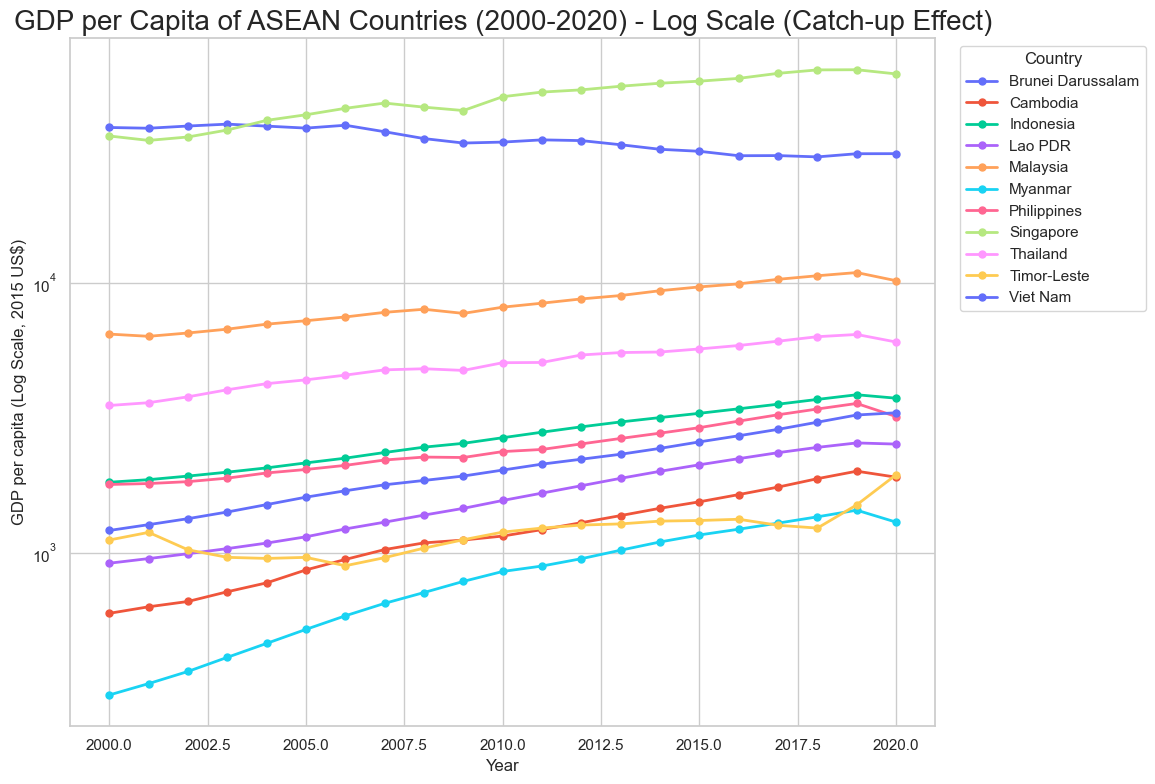

In [ ]:
df_gdp = (
    df[['Country Name', 'Year', 'GDP per capita (constant 2015 US$)']]
    .dropna()
    .sort_values(['Country Name', 'Year'])
)

value_col = 'GDP per capita (constant 2015 US$)'

country_order = [
    'Brunei Darussalam',
    'Cambodia',
    'Indonesia',
    'Lao PDR',
    'Malaysia',
    'Myanmar',
    'Philippines',
    'Singapore',
    'Thailand',
    'Timor-Leste',
    'Viet Nam'
]

plotly_colors = [
    '#636EFA',  # Brunei Darussalam
    '#EF553B',  # Cambodia
    '#00CC96',  # Indonesia
    '#AB63FA',  # Lao PDR
    '#FFA15A',  # Malaysia
    '#19D3F3',  # Myanmar
    '#FF6692',  # Philippines
    '#B6E880',  # Singapore
    '#FF97FF',  # Thailand
    '#FECB52',  # Timor-Leste
    '#FFCD00'   # Viet Nam
]

color_map = dict(zip(country_order, plotly_colors))

sns.set_theme(style="whitegrid")

fig_linear, ax_linear = plt.subplots(figsize=(14, 8))

for country in country_order:
    country_data = df_gdp[df_gdp['Country Name'] == country]
    if not country_data.empty:
        ax_linear.plot(
            country_data['Year'],
            country_data[value_col],
            marker='o',
            linewidth=2,
            markersize=5,
            label=country,
            color=color_map[country]
        )

ax_linear.set_title(
    "GDP per Capita of ASEAN Countries (2000-2020) - Linear Scale",
    fontsize=20
)
ax_linear.set_xlabel("Year")
ax_linear.set_ylabel("GDP per capita (2015 US$)")
ax_linear.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
fig_linear.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()

fig_log, ax_log = plt.subplots(figsize=(14, 8))

for country in country_order:
    country_data = df_gdp[df_gdp['Country Name'] == country]
    if not country_data.empty:
        ax_log.plot(
            country_data['Year'],
            country_data[value_col],
            marker='o',
            linewidth=2,
            markersize=5,
            label=country,
            color=color_map[country]
        )

ax_log.set_yscale('log')
ax_log.set_title(
    'GDP per Capita of ASEAN Countries (2000-2020) - Log Scale (Catch-up Effect)',
    fontsize=20
)
ax_log.set_xlabel("Year")
ax_log.set_ylabel("GDP per capita (Log Scale, 2015 US$)")
ax_log.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
fig_log.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()


- **Overview analysis:** The charts reveal a profound economic polarization within the ASEAN region into three distinct groups. The high-income group is isolated at the top, while the CLMV trend lines rise sharply, proving efforts to bridge the development gap.

- **Observations and trends drawn from the data:**
  - Singapore shows stable and outstanding growth, leading the region at ~$59,189 in 2020.
  - Brunei is the only ASEAN country with negative growth (-19.98% over 20 years), losing its top position to Singapore.
  - The CLMV group has the fastest percentage growth rate, with Myanmar (+335.8%) and Cambodia (+218.8%) leading the acceleration. Vietnam surpassed the Philippines.
  - The absolute monetary gap between the richest country and the rest continues to widen despite the high percentage growth of poorer nations.

- **Inclusion:**
  - ASEAN is a region with extreme economic diversity and polarization.
  - Developing countries drive the region's growth, while resource-dependent economies face stagnation.

#### 12. Measure the level of trade integration of ASEAN countries to identify which nations have the highest and lowest economic openness, and analyze their trends over time.

- **Data field:**
  - `Trade (% of GDP)`: Represents the total value of exports and imports of goods and services as a share of GDP. It is the primary indicator of a country's economic openness and integration into the global market.
  - `Exports of goods and services (% of GDP)`: Measures the contribution of international sales to the national economy.
  - `Imports of goods and services (% of GDP)`: Indicates the economy's reliance on foreign goods and services.

- **Chart type:**
  - **Multi-line chart** for `Trade (% of GDP)` over time: Best suited for visualizing long-term trends and comparing the trajectory of economic openness across all 11 countries.
  - **Grouped Bar chart** for `Exports` and `Imports` at milestone years (2000, 2010, 2020): Allows for a detailed cross-sectional comparison of the trade balance structure (Export vs. Import ratios) during key decades.

- **Expected insight:** Singapore will stand out as an exceptionally open economy. Vietnam is likely to show a rapid increase in trade openness in the later period. Economies with massive domestic markets, like Indonesia, usually exhibit lower trade-to-GDP ratios compared to highly open ones.

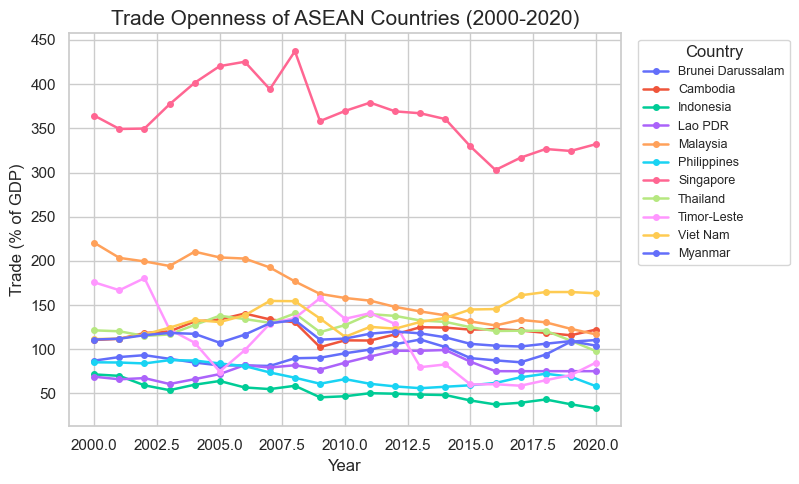

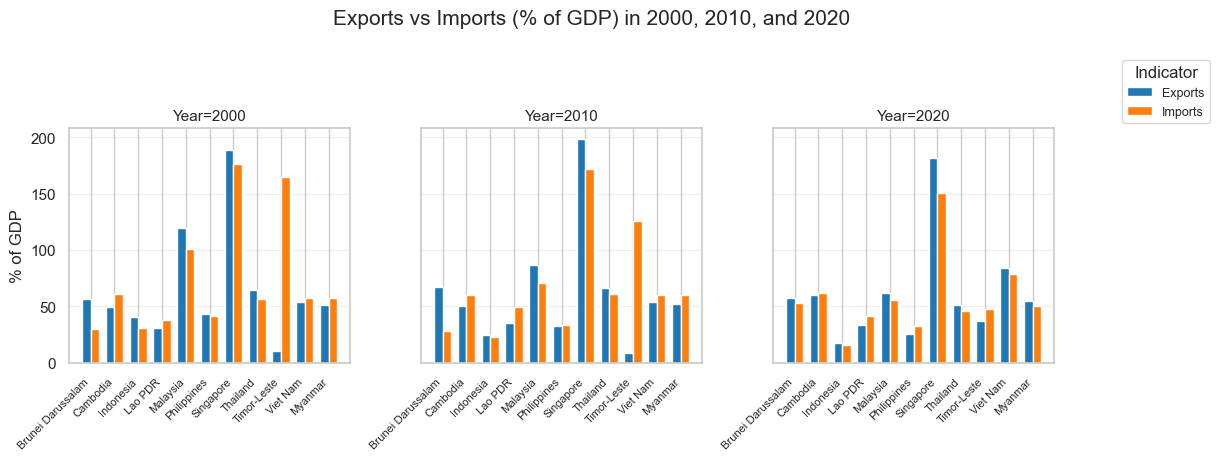

In [ ]:
sns.set_theme(style="whitegrid")

df_trade = (
    df[['Country Name', 'Year', 'Trade (% of GDP)']]
    .dropna()
    .sort_values(['Country Name', 'Year'])
)

plotly_country_colors = {
    'Brunei Darussalam': '#636EFA',
    'Cambodia': '#EF553B',
    'Indonesia': '#00CC96',
    'Lao PDR': '#AB63FA',
    'Malaysia': '#FFA15A',
    'Philippines': '#19D3F3',
    'Singapore': '#FF6692',
    'Thailand': '#B6E880',
    'Timor-Leste': '#FF97FF',
    'Viet Nam': '#FECB52'
}

preferred_country_order = [
    'Brunei Darussalam',
    'Cambodia',
    'Indonesia',
    'Lao PDR',
    'Malaysia',
    'Philippines',
    'Singapore',
    'Thailand',
    'Timor-Leste',
    'Viet Nam'
]

available_trade_countries = df_trade['Country Name'].unique().tolist()
country_order_trade = [
    c for c in preferred_country_order if c in available_trade_countries
] + [
    c for c in available_trade_countries if c not in preferred_country_order
]

fig_line, ax_line = plt.subplots(figsize=(10, 5))

for country in country_order_trade:
    country_data = df_trade[df_trade['Country Name'] == country]
    ax_line.plot(
        country_data['Year'],
        country_data['Trade (% of GDP)'],
        marker='o',
        linewidth=1.8,
        markersize=4,
        label=country,
        color=plotly_country_colors.get(country, '#636EFA')
    )

ax_line.set_title("Trade Openness of ASEAN Countries (2000-2020)", fontsize=15)
ax_line.set_xlabel("Year")
ax_line.set_ylabel("Trade (% of GDP)")
ax_line.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig_line.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

milestone_years = [2000, 2010, 2020]
df_milestones = df[df['Year'].isin(milestone_years)][[
    'Country Name', 'Year',
    'Exports of goods and services (% of GDP)',
    'Imports of goods and services (% of GDP)'
]].dropna()

df_melted = df_milestones.melt(
    id_vars=['Country Name', 'Year'],
    value_vars=[
        'Exports of goods and services (% of GDP)',
        'Imports of goods and services (% of GDP)'
    ],
    var_name='Trade Type',
    value_name='Percentage'
)

df_melted['Trade Type'] = df_melted['Trade Type'].replace({
    'Exports of goods and services (% of GDP)': 'Exports',
    'Imports of goods and services (% of GDP)': 'Imports'
})

trade_type_colors = {
    'Exports': '#1f77b4',
    'Imports': '#ff7f0e'
}

available_bar_countries = df_melted['Country Name'].unique().tolist()
country_order_bar = [
    c for c in preferred_country_order if c in available_bar_countries
] + [
    c for c in available_bar_countries if c not in preferred_country_order
]

fig_bar, axes = plt.subplots(1, 3, figsize=(12, 4.5), sharey=True)
bar_width = 0.36
legend_handles = None

for ax, year in zip(axes, milestone_years):
    year_data = df_melted[df_melted['Year'] == year]
    pivot = (
        year_data
        .pivot(index='Country Name', columns='Trade Type', values='Percentage')
        .reindex(country_order_bar)
    )

    x = np.arange(len(country_order_bar))
    exports = pivot['Exports'].to_numpy() if 'Exports' in pivot.columns else np.full(len(country_order_bar), np.nan)
    imports = pivot['Imports'].to_numpy() if 'Imports' in pivot.columns else np.full(len(country_order_bar), np.nan)

    bars_exports = ax.bar(
        x - bar_width / 2,
        exports,
        width=bar_width,
        color=trade_type_colors['Exports'],
        label='Exports'
    )
    bars_imports = ax.bar(
        x + bar_width / 2,
        imports,
        width=bar_width,
        color=trade_type_colors['Imports'],
        label='Imports'
    )

    if legend_handles is None:
        legend_handles = [bars_exports, bars_imports]

    ax.set_title(f"Year={year}", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(country_order_bar, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel("% of GDP")

fig_bar.suptitle("Exports vs Imports (% of GDP) in 2000, 2010, and 2020", fontsize=15, y=1.02)
fig_bar.legend(
    legend_handles,
    ['Exports', 'Imports'],
    title="Indicator",
    bbox_to_anchor=(1.02, 0.92),
    loc="upper right",
    fontsize=9
)

fig_bar.tight_layout(rect=(0, 0, 0.9, 0.92))
plt.show()


- **Overview analysis:** The visualization highlights a stark contrast in trade strategies within ASEAN. While most countries maintain a moderate trade-to-GDP ratio (between 50% and 150%), Singapore and Vietnam emerge as outliers with extraordinary levels of global trade integration. Conversely, the largest economies by population tend to have the lowest trade openness.

- **Observations and trends drawn from the data:**
  - **Singapore as an Entrepôt:** Singapore's trade-to-GDP ratio is exceptionally high, consistently fluctuating over 300% (reaching ~332% in 2020). Its exports (~181%) and imports (~150%) far exceed its actual GDP, emphasizing its role as a global transshipment and financial hub.
  - **Vietnam's spectacular rise:** Vietnam demonstrated the most impressive growth in trade integration, surging from ~111% in 2000 to ~163% in 2020. This transformation reflects Vietnam's successful strategy in attracting FDI and becoming a key manufacturing hub in the global supply chain.
  - **Large domestic markets:** Indonesia and the Philippines possess the lowest trade-to-GDP ratios in the region. Indonesia's trade openness actually declined from ~71% in 2000 down to roughly ~33% in 2020. This indicates that their economic growth relies heavily on domestic consumption rather than international trade.
  - **Trade Balance:** The grouped bar chart reveals that most ASEAN countries maintain a relatively balanced export-import structure, although structural shifts occurred over the decades depending on industrialization phases.

- **Inclusion:**
  - ASEAN countries exhibit vastly different models of economic growth.
  - Small to medium-sized nations (Singapore, Vietnam, Malaysia) leverage global trade as their primary economic driver.
  - Heavily populated countries (Indonesia, Philippines) are less exposed to global trade shocks due to their reliance on vast domestic markets.

#### 13. Analyze the relationship between FDI inflows and economic growth to determine if foreign direct investment coincides with periods of rapid expansion.

- **Data field:**
  - `Foreign direct investment, net inflows (% of GDP)`: Represents the amount of foreign capital flowing into the country, a major driver of industrialization and infrastructure development.
  - `GDP per capita growth (annual %)`: Measures the annual economic expansion relative to the population, indicating periods of rapid growth or recession.
  - `Exports of goods and services (% of GDP)`: Reflects the integration of the economy into the global supply chain, often fueled by FDI.

- **Chart type:**
  - **Scatter plot (Bubble Chart)**: To visualize the correlation between FDI inflows and GDP per capita growth across all ASEAN countries. The bubble size represents the export-to-GDP ratio to reveal the triad relationship.
  - **Dual-axis subplots**: For representative countries (Vietnam, Indonesia, Cambodia) to observe the time-series trend of FDI (bar) alongside economic growth (line) on the same timeline.

- **Expected insight:** Industrializing countries might show periods where increased FDI corresponds with higher per capita growth. The effect of FDI might be clearer when accompanied by export expansion. The relationship is not perfectly linear, meaning there are periods of high FDI without correspondingly high growth.

- **Data field:**
  - `Foreign direct investment, net inflows (% of GDP)`: Represents the amount of foreign capital flowing into the country, a major driver of industrialization and infrastructure development.
  - `GDP per capita growth (annual %)`: Measures the annual economic expansion relative to the population, indicating periods of rapid growth or recession.
  - `Exports of goods and services (% of GDP)`: Reflects the integration of the economy into the global supply chain, often fueled by FDI.

- **Chart type:**
  - **Scatter plot (Bubble Chart)**: To visualize the correlation between FDI inflows and GDP per capita growth across all ASEAN countries. The bubble size represents the export-to-GDP ratio to reveal the triad relationship.
  - **Dual-axis subplots**: For representative countries (Vietnam, Indonesia, Cambodia) to observe the time-series trend of FDI (bar) alongside economic growth (line) on the same timeline.

- **Expected insight:** Industrializing countries might show periods where increased FDI corresponds with higher per capita growth. The effect of FDI might be clearer when accompanied by export expansion. The relationship is not perfectly linear, meaning there are periods of high FDI without correspondingly high growth.

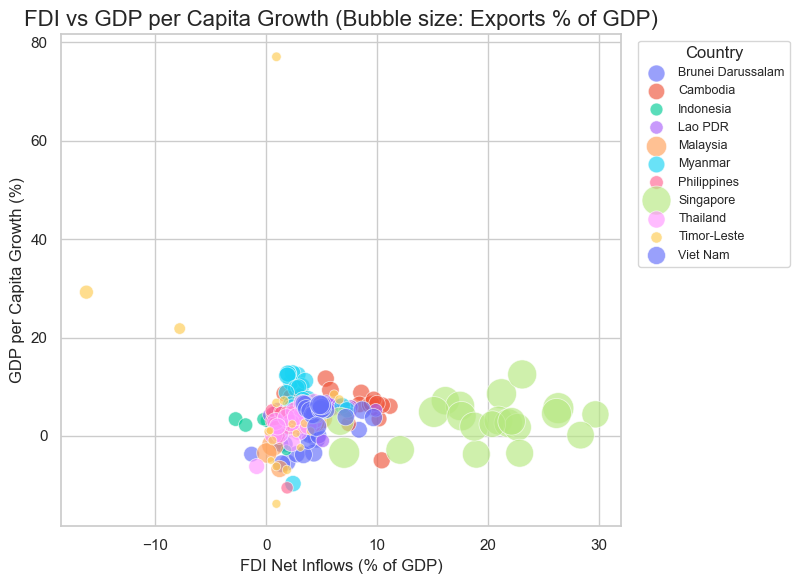

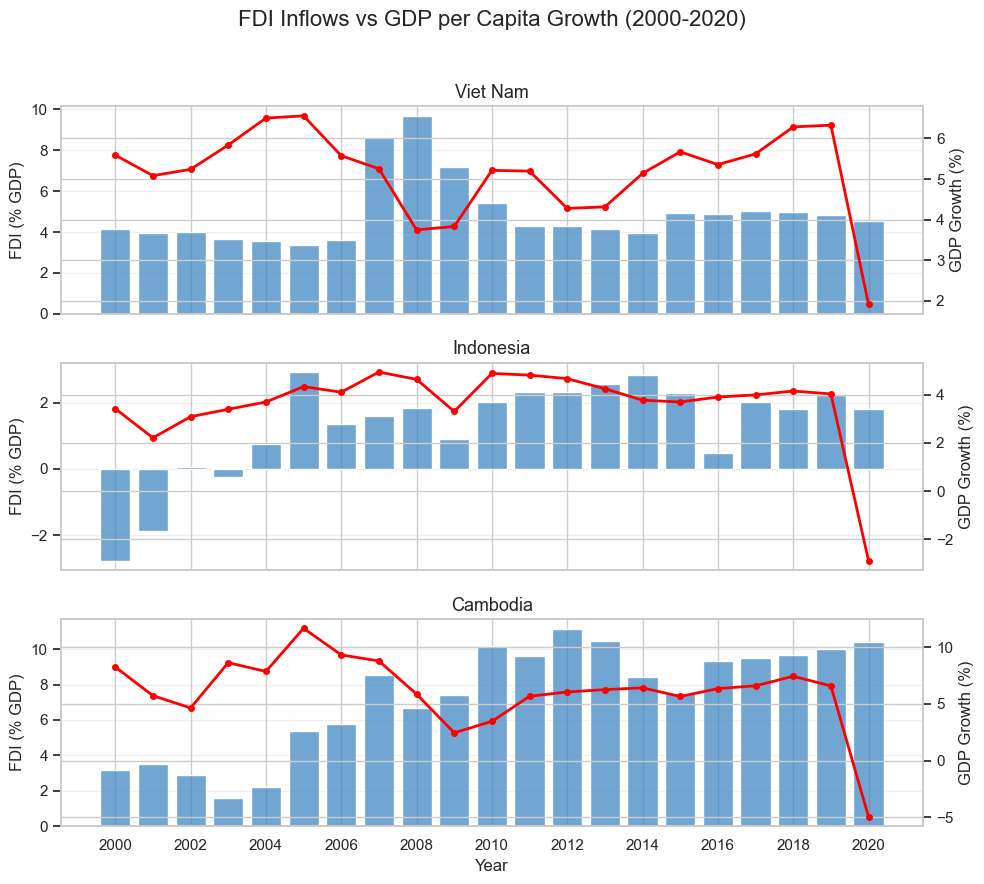

In [ ]:
sns.set_theme(style="whitegrid")

df_scatter = df.dropna(subset=[
    'Foreign direct investment, net inflows (% of GDP)',
    'GDP per capita growth (annual %)',
    'Exports of goods and services (% of GDP)'
]).copy()

plotly_country_colors = {
    'Brunei Darussalam': '#636EFA',
    'Cambodia': '#EF553B',
    'Indonesia': '#00CC96',
    'Lao PDR': '#AB63FA',
    'Malaysia': '#FFA15A',
    'Myanmar': '#19D3F3',
    'Philippines': '#FF6692',
    'Singapore': '#B6E880',
    'Thailand': '#FF97FF',
    'Timor-Leste': '#FECB52',
    'Viet Nam': '#636EFA'
}

preferred_country_order = [
    'Brunei Darussalam',
    'Cambodia',
    'Indonesia',
    'Lao PDR',
    'Malaysia',
    'Myanmar',
    'Philippines',
    'Singapore',
    'Thailand',
    'Timor-Leste',
    'Viet Nam'
]

available_scatter_countries = df_scatter['Country Name'].unique().tolist()
country_order_scatter = [
    c for c in preferred_country_order if c in available_scatter_countries
] + [
    c for c in available_scatter_countries if c not in preferred_country_order
]

exports = df_scatter['Exports of goods and services (% of GDP)']
size_min, size_max = 30, 500
df_scatter['Bubble Size'] = size_min + (
    (exports - exports.min()) / (exports.max() - exports.min())
) * (size_max - size_min)

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

for country in country_order_scatter:
    country_data = df_scatter[df_scatter['Country Name'] == country]
    ax_scatter.scatter(
        country_data['Foreign direct investment, net inflows (% of GDP)'],
        country_data['GDP per capita growth (annual %)'],
        s=country_data['Bubble Size'],
        color=plotly_country_colors.get(country, '#636EFA'),
        alpha=0.65,
        edgecolors='white',
        linewidths=0.6,
        label=country
    )

ax_scatter.set_title(
    "FDI vs GDP per Capita Growth (Bubble size: Exports % of GDP)",
    fontsize=16
)
ax_scatter.set_xlabel("FDI Net Inflows (% of GDP)")
ax_scatter.set_ylabel("GDP per Capita Growth (%)")
ax_scatter.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
fig_scatter.tight_layout(rect=(0, 0, 0.82, 1))
plt.show()

countries_to_plot = ["Viet Nam", "Indonesia", "Cambodia"]

fig_dual, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

for ax, country in zip(axes, countries_to_plot):
    df_country = (
        df[df["Country Name"] == country]
        .sort_values("Year")
        .dropna(subset=[
            "Foreign direct investment, net inflows (% of GDP)",
            "GDP per capita growth (annual %)"
        ])
    )

    ax_right = ax.twinx()

    ax.bar(
        df_country["Year"],
        df_country["Foreign direct investment, net inflows (% of GDP)"],
        color=(55/255, 128/255, 191/255, 0.7),
        width=0.8
    )

    ax_right.plot(
        df_country["Year"],
        df_country["GDP per capita growth (annual %)"],
        color='red',
        marker='o',
        linewidth=2,
        markersize=4
    )

    ax.set_title(country, fontsize=13)
    ax.set_ylabel("FDI (% GDP)")
    ax_right.set_ylabel("GDP Growth (%)")
    ax.set_xticks(np.arange(2000, 2021, 2))
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel("Year")
fig_dual.suptitle("FDI Inflows vs GDP per Capita Growth (2000-2020)", fontsize=16, y=0.98)
fig_dual.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


- **Overview analysis:** The data reveals that FDI is a crucial catalyst for economic growth in developing ASEAN nations, but it is not a standalone magic bullet. The positive impact of FDI on GDP growth is most pronounced when the investment translates into export-oriented manufacturing capacities (like in Vietnam and Cambodia).

- **Observations and trends drawn from the data:**
  - **Positive correlation with volatility:** The scatter plot indicates a general positive relationship between FDI and GDP per capita growth, though with significant dispersion. High FDI does not always guarantee immediate high growth due to lag effects or global economic shocks (e.g., 2008 or 2020).
  - **Vietnam's export-driven FDI model:** In Vietnam, steady FDI inflows directly correlate with sustained GDP growth and a massive surge in exports. This highlights a successful model where foreign capital is utilized to build robust export industries.
  - **Cambodia's reliance on FDI:** Cambodia exhibits extremely high FDI inflows relative to its GDP (frequently exceeding 10%), which coincided with its golden period of rapid GDP growth (often above 5-6% annually before the 2020 pandemic).
  - **Indonesia's domestic focus:** Despite having lower FDI as a percentage of GDP compared to Vietnam, Indonesia maintains stable GDP growth. This underscores its reliance on a massive domestic consumption market rather than purely FDI-driven exports.

- **Inclusion:**
  - FDI is strongly associated with rapid economic growth, particularly in developing economies transitioning to export-oriented manufacturing.
  - However, the relationship is non-linear; the economic benefits of FDI are maximized when aligned with strategic export expansion rather than just capital absorption.

#### 14. Analyze the external debt vulnerability of ASEAN countries by comparing debt scale, debt service burden, and foreign exchange reserve capacity.

- **Data field:**
  - `External debt stocks (% of GNI)`: Indicates the overall size of the external debt relative to the nation's total income.
  - `Debt service (% of exports)`: Measures the immediate financial burden of repaying debt obligations using export earnings. High values indicate severe liquidity pressure.
  - `Total reserves (% of total external debt)`: Acts as a primary buffer; shows how much of the debt could be covered by existing foreign reserves.
  - `Total reserves in months of imports`: Evaluates the country's ability to survive external shocks by measuring how many months of imports the reserves can sustain.

- **Chart type:**
  - **Bubble Scatter Plot**: X-axis (`Debt scale`), Y-axis (`Debt service burden`), and Bubble Size (`Total reserves % of external debt`). This visually separates highly vulnerable nations (top-right, tiny bubble) from resilient ones (bottom-left, giant bubble).
  - **Lollipop Chart**: Ranks the `Total reserves in months of imports`. A lollipop chart is less cluttered than a bar chart and effectively highlights rankings and safe-zone thresholds (typically 3-6 months is considered safe).

- **Expected insight:** Countries with high debt and low reserves will emerge as the most vulnerable group. Some may have moderate debt but a high debt service burden. Total reserves act as a crucial cushion, meaning high debt isn't inherently bad if backed by massive reserves. *(Note: Advanced economies like Singapore and Brunei do not report to the World Bank's Debtor Reporting System, naturally focusing the analysis on developing ASEAN nations).*

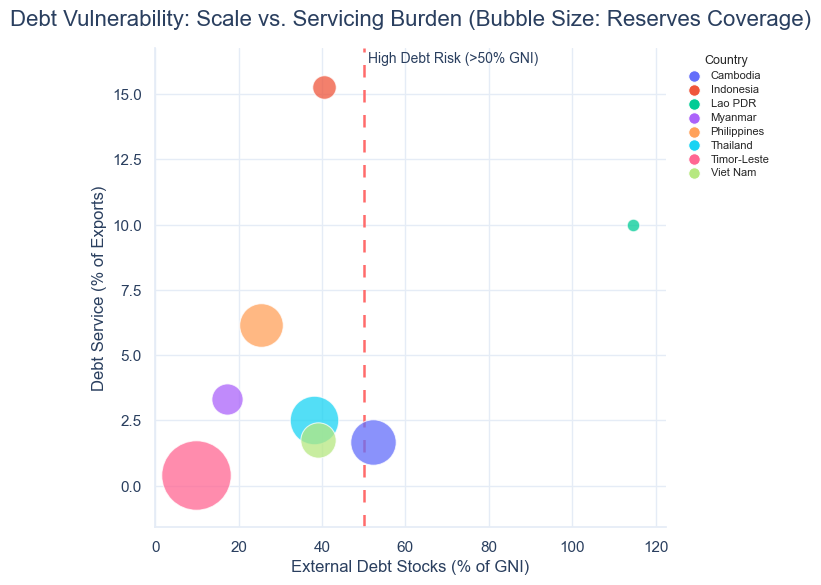

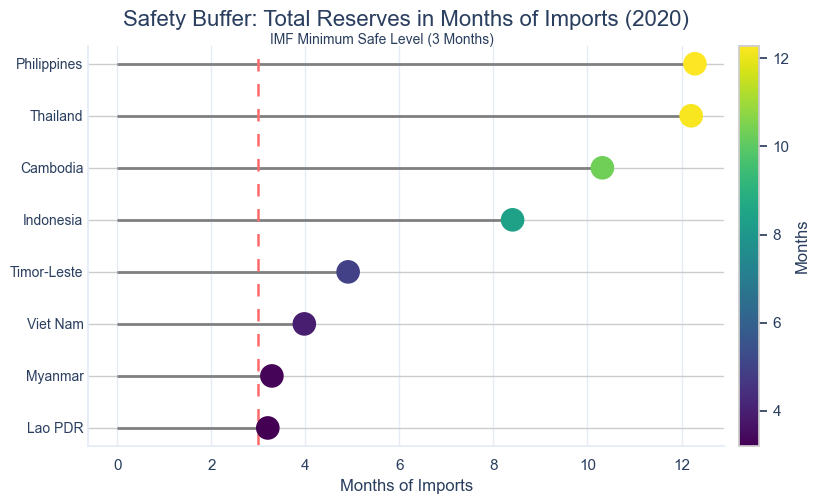

In [ ]:
import matplotlib.pyplot as plt

df_debt = df[df['Year'] == 2020][[
    'Country Name',
    'External debt stocks (% of GNI)',
    'Debt service (PPG and IMF only, % of exports of goods, services and primary income)',
    'Total reserves (% of total external debt)',
    'Total reserves in months of imports'
]].dropna().copy()

# Keep Plotly default discrete colors in the same filtered order
plotly_colors = [
    '#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A',
    '#19D3F3', '#FF6692', '#B6E880', '#FF97FF', '#FECB52'
]

country_order = df_debt['Country Name'].drop_duplicates().tolist()
color_map = {
    country: plotly_colors[i % len(plotly_colors)]
    for i, country in enumerate(country_order)
}

x_col = 'External debt stocks (% of GNI)'
y_col = 'Debt service (PPG and IMF only, % of exports of goods, services and primary income)'
size_col = 'Total reserves (% of total external debt)'

size_max = 50
max_size_value = df_debt[size_col].max()
if max_size_value > 0:
    df_debt['bubble_size'] = (df_debt[size_col] / max_size_value) * (size_max ** 2)
else:
    df_debt['bubble_size'] = size_max ** 2

fig_bubble, ax_bubble = plt.subplots(figsize=(8.8, 6.2), dpi=100)

for country in country_order:
    country_data = df_debt[df_debt['Country Name'] == country]
    ax_bubble.scatter(
        country_data[x_col],
        country_data[y_col],
        s=country_data['bubble_size'],
        color=color_map[country],
        alpha=0.75,
        edgecolors='white',
        linewidths=0.8,
        label=country,
        zorder=3
    )

x_min = min(0, df_debt[x_col].min() - 5)
x_max = df_debt[x_col].max() + 8
y_min = df_debt[y_col].min() - 2
y_max = df_debt[y_col].max() + 1.5

ax_bubble.set_xlim(x_min, x_max)
ax_bubble.set_ylim(y_min, y_max)

ax_bubble.axvline(50, linestyle=(0, (5, 5)), color='#FF6B6B', linewidth=1.8, zorder=2)
ax_bubble.text(
    51,
    y_max - 0.15,
    'High Debt Risk (>50% GNI)',
    color='#2a3f5f',
    fontsize=10,
    va='top'
)

ax_bubble.set_title(
    'Debt Vulnerability: Scale vs. Servicing Burden (Bubble Size: Reserves Coverage)',
    fontsize=16,
    pad=16,
    color='#2a3f5f'
)
ax_bubble.set_xlabel('External Debt Stocks (% of GNI)', fontsize=12, color='#2a3f5f')
ax_bubble.set_ylabel('Debt Service (% of Exports)', fontsize=12, color='#2a3f5f')

ax_bubble.grid(True, color='#E5ECF6')
ax_bubble.set_facecolor('white')
ax_bubble.tick_params(axis='both', colors='#2a3f5f', labelsize=11)

for spine in ['top', 'right']:
    ax_bubble.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_bubble.spines[spine].set_color('#E5ECF6')

legend = ax_bubble.legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
    fontsize=8,
    title_fontsize=9,
    labelspacing=0.35,
    handletextpad=0.5,
    borderaxespad=0.2,
    scatterpoints=1,
    markerscale=0.55
)

for handle in legend.legend_handles:
    handle.set_sizes([70])
    handle.set_alpha(1)

fig_bubble.tight_layout(rect=(0, 0, 0.82, 0.97))
plt.show()

df_reserves = df_debt.sort_values(
    by='Total reserves in months of imports',
    ascending=True
).reset_index(drop=True)

fig_lollipop, ax_lollipop = plt.subplots(figsize=(8.8, 5.2), dpi=100)

y_pos = list(range(len(df_reserves)))
x_vals = df_reserves['Total reserves in months of imports']

for y, x in zip(y_pos, x_vals):
    ax_lollipop.hlines(y=y, xmin=0, xmax=x, color='gray', linewidth=2, zorder=1)

scatter = ax_lollipop.scatter(
    x_vals,
    y_pos,
    c=x_vals,
    cmap='viridis',
    s=16 ** 2,
    zorder=3
)

ax_lollipop.axvline(3, linestyle=(0, (5, 5)), color='#FF6B6B', linewidth=1.8, zorder=2)
ax_lollipop.text(
    3.25,
    len(y_pos) - 0.4,
    'IMF Minimum Safe Level (3 Months)',
    color='#2a3f5f',
    fontsize=10,
    va='top'
)

ax_lollipop.set_yticks(y_pos)
ax_lollipop.set_yticklabels(df_reserves['Country Name'], fontsize=10, color='#2a3f5f')
ax_lollipop.set_xlabel('Months of Imports', fontsize=12, color='#2a3f5f')
ax_lollipop.set_ylabel('')
ax_lollipop.set_title(
    'Safety Buffer: Total Reserves in Months of Imports (2020)',
    fontsize=16,
    pad=14,
    color='#2a3f5f'
)

ax_lollipop.grid(True, axis='x', color='#E5ECF6')
ax_lollipop.set_facecolor('white')
ax_lollipop.tick_params(axis='x', colors='#2a3f5f', labelsize=11)
ax_lollipop.tick_params(axis='y', length=0)

for spine in ['top', 'right']:
    ax_lollipop.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_lollipop.spines[spine].set_color('#E5ECF6')

cbar = plt.colorbar(scatter, ax=ax_lollipop, pad=0.02)
cbar.set_label('Months', color='#2a3f5f')
cbar.ax.tick_params(colors='#2a3f5f')

fig_lollipop.tight_layout()
plt.show()


- **Overview analysis:** The visualization starkly contrasts the debt resilience within developing ASEAN nations. While most countries maintain manageable debt levels backed by strong foreign reserves, a few specific nations exhibit alarming signs of debt distress.

- **Observations and trends drawn from the data:**
  - **The Highly Vulnerable (Lao PDR):** Laos stands out as the most vulnerable economy. It has an immense external debt exceeding 100% of its GNI, a heavy debt service burden (approx. 10-11% of exports), and a dangerously small reserve buffer (small bubble).
  - **The Liquidity Squeeze (Indonesia):** Indonesia's overall debt stock is moderate (~40% of GNI), but its debt service burden is the highest in the group (>15% of exports). This indicates that while the debt isn't overwhelmingly huge, the cost of servicing it puts heavy pressure on its export revenues.
  - **The Highly Resilient:** Thailand and the Philippines showcase excellent macroeconomic stability. Both have relatively low debt service burdens and massive foreign exchange reserves (represented by large bubbles), making them highly resilient to external financial shocks.
  - **Import Survival Buffer:** The Lollipop chart reveals that Thailand and the Philippines can sustain over 12 months of imports using their reserves (way above the global standard of 3 months). Conversely, Laos and Myanmar hover dangerously close to the 3-month minimum threshold.

- **Inclusion:**
  - Assessing debt requires looking beyond just the total owed; the ability to service the debt and the reserve buffers are far more critical.
  - While major ASEAN economies have fortified their reserves since the 1997 Asian Financial Crisis, smaller economies like Laos remain highly exposed to external debt traps.

#### 15. Compare the domestic accumulation capability against the reliance on external resources to identify the underlying growth models of ASEAN countries.

- **Data field:**
  - `Gross savings (% of GDP)`: Represents domestic capital accumulation. High savings mean the country can fund its own investments without relying on foreign debt.
  - `Foreign direct investment, net inflows (% of GDP)`: Measures the level of dependency on external capital for economic expansion.
  - `Current account balance (% of GDP)`: Indicates whether a country is a net lender (surplus) or net borrower (deficit) to the rest of the world. Chronic deficits combined with low savings signal high vulnerability.

- **Chart type:** **Quadrant Scatter Plot**. 
  - The X-axis represents `Gross savings` and the Y-axis represents `FDI inflows`. 
  - Intersecting reference lines (using the regional medians) divide the chart into four distinct quadrants, categorizing countries into different growth models (e.g., Domestically Funded vs. Foreign Capital Dependent). 
  - Bubble colors denote the `Current Account Balance` (Blue for Surplus, Red for Deficit) to instantly flag macroeconomic vulnerabilities.

- **Expected insight:** Some countries grow primarily through domestic accumulation, while others rely heavily on external capital. Nations with high Gross Savings generally possess better resilience against external shocks. Conversely, those with low savings and chronic current account deficits are highly vulnerable and require close monitoring.

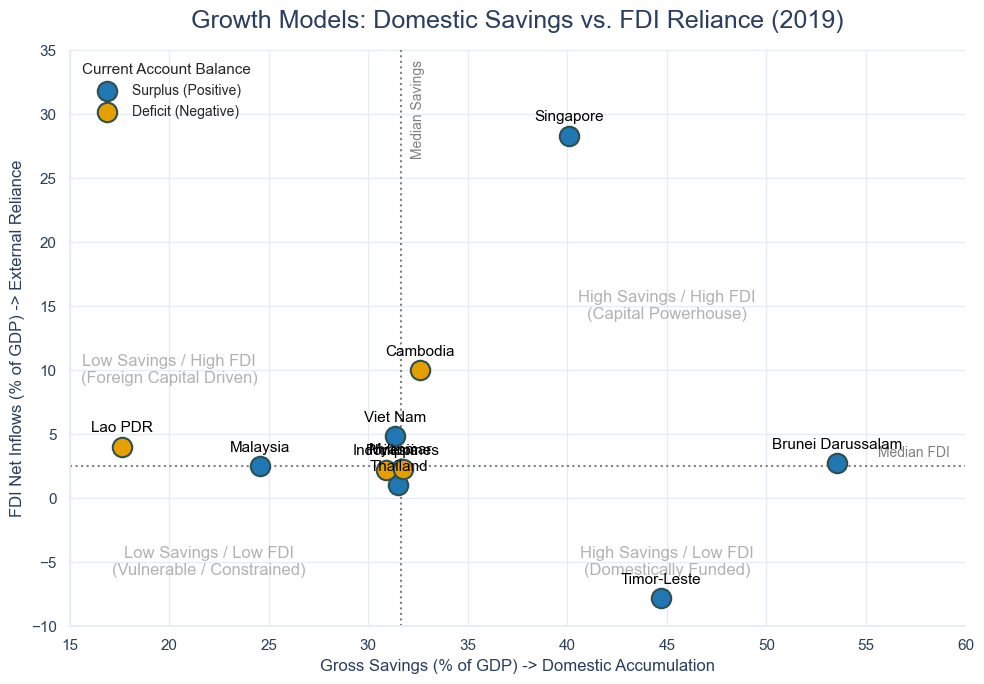

In [ ]:
import matplotlib.pyplot as plt

df_model = df[df['Year'] == 2019][[
    'Country Name',
    'Gross savings (% of GDP)',
    'Foreign direct investment, net inflows (% of GDP)',
    'Current account balance (% of GDP)'
]].dropna().copy()

df_model['Account Status'] = df_model['Current account balance (% of GDP)'].apply(
    lambda x: 'Surplus (Positive)' if x > 0 else 'Deficit (Negative)'
)

median_savings = df_model['Gross savings (% of GDP)'].median()
median_fdi = df_model['Foreign direct investment, net inflows (% of GDP)'].median()

status_colors = {
    'Surplus (Positive)': '#1f77b4',
    'Deficit (Negative)': '#e69f00'
}

fig_quad, ax_quad = plt.subplots(figsize=(10, 7), dpi=100)

for status in ['Surplus (Positive)', 'Deficit (Negative)']:
    subset = df_model[df_model['Account Status'] == status]
    ax_quad.scatter(
        subset['Gross savings (% of GDP)'],
        subset['Foreign direct investment, net inflows (% of GDP)'],
        s=14 ** 2,
        color=status_colors[status],
        edgecolors='DarkSlateGrey',
        linewidths=1.5,
        label=status,
        zorder=3
    )

for _, row in df_model.iterrows():
    ax_quad.annotate(
        row['Country Name'],
        (
            row['Gross savings (% of GDP)'],
            row['Foreign direct investment, net inflows (% of GDP)']
        ),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=11,
        color='black',
        zorder=4
    )

ax_quad.set_xlim(15, 60)
ax_quad.set_ylim(-10, 35)

ax_quad.axhline(median_fdi, linestyle=':', color='gray', linewidth=1.5, zorder=2)
ax_quad.axvline(median_savings, linestyle=':', color='gray', linewidth=1.5, zorder=2)

ax_quad.text(
    59.2, median_fdi + 0.5, 'Median FDI',
    color='gray', fontsize=10, ha='right', va='bottom'
)
ax_quad.text(
    median_savings + 0.5, 34.2, 'Median Savings',
    color='gray', fontsize=10, ha='left', va='top', rotation=90
)

ax_quad.text(
    45, 15,
    'High Savings / High FDI\n(Capital Powerhouse)',
    color='gray', fontsize=12, alpha=0.6,
    ha='center', va='center'
)
ax_quad.text(
    20, 10,
    'Low Savings / High FDI\n(Foreign Capital Driven)',
    color='gray', fontsize=12, alpha=0.6,
    ha='center', va='center'
)
ax_quad.text(
    45, -5,
    'High Savings / Low FDI\n(Domestically Funded)',
    color='gray', fontsize=12, alpha=0.6,
    ha='center', va='center'
)
ax_quad.text(
    22, -5,
    'Low Savings / Low FDI\n(Vulnerable / Constrained)',
    color='gray', fontsize=12, alpha=0.6,
    ha='center', va='center'
)

ax_quad.set_title(
    'Growth Models: Domestic Savings vs. FDI Reliance (2019)',
    fontsize=18,
    pad=16,
    color='#2a3f5f'
)
ax_quad.set_xlabel(
    'Gross Savings (% of GDP) -> Domestic Accumulation',
    fontsize=12,
    color='#2a3f5f'
)
ax_quad.set_ylabel(
    'FDI Net Inflows (% of GDP) -> External Reliance',
    fontsize=12,
    color='#2a3f5f'
)

ax_quad.grid(True, color='#E5ECF6')
ax_quad.set_facecolor('white')
ax_quad.tick_params(axis='both', colors='#2a3f5f', labelsize=11)

for spine in ['top', 'right']:
    ax_quad.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax_quad.spines[spine].set_color('#E5ECF6')

ax_quad.legend(
    title='Current Account Balance',
    loc='upper left',
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

fig_quad.tight_layout()
plt.show()


- **Overview analysis:** The Quadrant Chart clearly segments ASEAN into distinct economic models. While Singapore acts as a unique capital powerhouse (excelling in both domestic savings and FDI), the developing nations face a trade-off. The data highlights a stark contrast between self-reliant resource exporters and rapidly industrializing nations fueled by foreign capital.

- **Observations and trends drawn from the data:**
  - **The Capital Powerhouse (Top-Right):** Singapore is an outlier. It boasts immense domestic savings (~40% of GDP) while simultaneously attracting the highest FDI in the region (>28%), operating with a massive current account surplus.
  - **Foreign-Capital Driven Growth (Top-Left):** Cambodia and Vietnam heavily rely on FDI to drive their industrialization. However, Cambodia's model is riskier; its high FDI absorption is coupled with a severe current account deficit (red bubble), meaning it heavily imports capital and goods to sustain growth.
  - **Domestically Funded / Self-Reliant (Bottom-Right):** Brunei and Thailand have high gross savings but low FDI inflows. They rely on their own accumulated wealth to fund domestic activities and maintain healthy current account surpluses (blue bubbles).
  - **The Vulnerable Group (Bottom-Left):** Lao PDR and Indonesia show lower domestic savings and lower FDI compared to the regional median, alongside current account deficits. Lao PDR is particularly vulnerable as it has the lowest gross savings in the region (<18%), making its economy highly susceptible to external financial shocks and debt crises.

- **Inclusion:**
  - ASEAN growth models are diverse: from self-funding economies to FDI-dependent industrializers.
  - High gross savings provide a critical shock absorber. Countries like Lao PDR and Cambodia, which run on current account deficits and rely heavily on external financing, must carefully manage their macroeconomic stability to avoid future crises.